In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np

In [3]:
data = load_breast_cancer()

In [4]:
data.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [5]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [7]:
data.data.shape

(569, 30)

In [8]:
rfc = RandomForestClassifier(n_estimators=25, random_state=42)
score = cross_val_score(rfc, data.data,data.target, cv=10).mean()

score

0.9666040100250626

In [9]:
scorel = []

for i in range(0, 200, 10):
    rfc = RandomForestClassifier(n_estimators=i+1, random_state=42, n_jobs=-1)
    score = cross_val_score(rfc, data.data, data.target, cv=10).mean()
    
    scorel.append(score)


In [10]:
print(max(scorel), [*range(1, 201, 10)][scorel.index(max(scorel))])

0.968358395989975 21


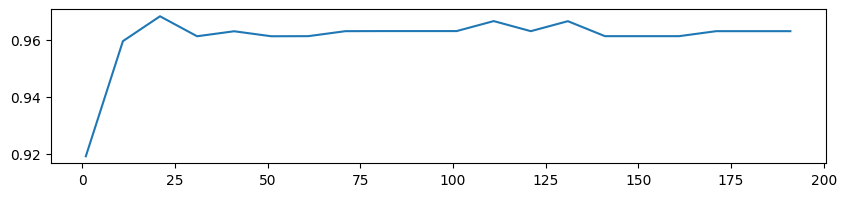

In [12]:
plt.figure(figsize=[10, 2])
plt.plot(range(1,201, 10), scorel)
plt.show()

In [13]:
scorel1 = []

for i in range(15, 28):
    rfc = RandomForestClassifier(n_estimators=i, random_state=42, n_jobs=-1)
    score = cross_val_score(rfc, data.data, data.target, cv=10).mean()
    
    scorel1.append(score)
    
print(max(scorel1), [*range(15, 28)][scorel1.index(max(scorel1))])

0.968358395989975 21


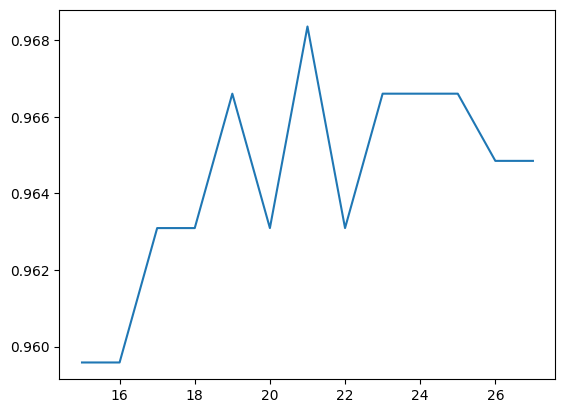

In [14]:
plt.plot(range(15, 28), scorel1)
plt.show()

再进行网格搜索

In [15]:
param_grid = {"max_depth": np.arange(1, 20, 1)}

rfc = RandomForestClassifier(n_estimators=21, random_state=42)

GS = GridSearchCV(rfc, param_grid, cv=10)
GS.fit(data.data, data.target)

GridSearchCV(cv=10,
             estimator=RandomForestClassifier(n_estimators=21, random_state=42),
             param_grid={'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19])})

In [16]:
GS.best_score_

0.9683897243107771

In [17]:
GS.best_params_

{'max_depth': 6}

In [18]:
# max_feature 调参
param_grid = {"max_features": np.arange(5, 30, 1)}

rfc = RandomForestClassifier(n_estimators=21, random_state=42,max_depth=6)
GS = GridSearchCV(rfc, param_grid, cv=10)
GS.fit(data.data, data.target)

GridSearchCV(cv=10,
             estimator=RandomForestClassifier(max_depth=6, n_estimators=21,
                                              random_state=42),
             param_grid={'max_features': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
       22, 23, 24, 25, 26, 27, 28, 29])})

In [19]:
GS.best_params_

{'max_features': 5}

In [20]:
GS.best_score_

0.9683897243107771

在尝试有限的max_depth后，发现准确率下降了，说明模型在最佳复杂度之前的曲线。

因此增加模型复杂度的方法还有：增加features，

可以发现默认的features数量就使得泛化误差最低了，模型处于最佳复杂度点，因此增加复杂度不能再优化泛化误差了。

In [23]:
# 尝试 min_samples_leaf
param_grid = {"min_samples_leaf": np.arange(1, 11, 1)}

rfc = RandomForestClassifier(n_estimators=21, random_state=42,max_depth=6, max_features=5)
GS = GridSearchCV(rfc, param_grid, cv=10)
GS.fit(data.data, data.target)

GridSearchCV(cv=10,
             estimator=RandomForestClassifier(max_depth=6, max_features=5,
                                              n_estimators=21,
                                              random_state=42),
             param_grid={'min_samples_leaf': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])})

In [24]:
GS.best_params_

{'min_samples_leaf': 1}

In [25]:
GS.best_score_

0.9683897243107771

验证了上述的分析结果